In [6]:
import pandas as pd
import numpy as np
from os import listdir
import torch
import torchaudio
import matplotlib.pyplot as plt

In [237]:
def loadDataAsSpectrogram(path:str)->dict[str:np.ndarray]:
    return {file:torchaudio.transforms.AmplitudeToDB()(torchaudio.transforms.Spectrogram()(torchaudio.load(path+file)[0]))[0] for file in listdir(path) if file.endswith('.wav')}

In [238]:
data = loadDataAsSpectrogram('.././data/audios_development/')

In [239]:
data

{'1.wav': tensor([[ -24.4217,  -35.0166,  -39.7268,  ...,  -27.9476,  -28.5529,
           -29.4887],
         [ -25.3887,  -36.9799,  -29.4063,  ...,  -14.1696,  -21.6521,
           -22.5368],
         [ -41.9817,  -32.6064,  -23.4189,  ...,   -8.6771,  -13.5843,
           -17.0098],
         ...,
         [ -62.0086, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
           -73.6433],
         [ -62.0230, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
           -73.6574],
         [ -62.0339, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
           -73.6556]]),
 '10.wav': tensor([[   3.7800,    3.7774,    0.6977,  ..., -100.0000, -100.0000,
          -100.0000],
         [  -2.7902,   -2.1215,   -4.0997,  ..., -100.0000, -100.0000,
          -100.0000],
         [ -21.6010,  -36.7062,  -17.7037,  ..., -100.0000, -100.0000,
          -100.0000],
         ...,
         [ -52.3381,  -58.8169,  -59.8193,  ..., -100.0000, -100.0000,
          -100.0000],
         [ -50.1991, 

In [240]:
def plotSignal(df:pd.DataFrame, index:str)->None:
    fig, ax = plt.subplots(1,1,figsize=(10,10))
    ax.set_title(index)
    ax.plot(df)
    
    ax.grid(visible=True)
    plt.show()
    plt.tight_layout()

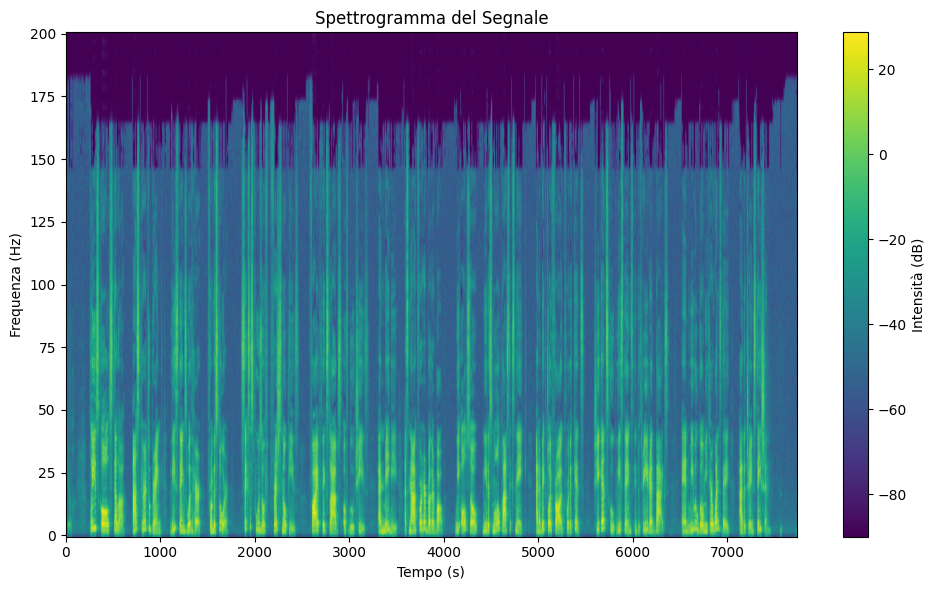

In [241]:
import torchaudio
import matplotlib.pyplot as plt
import torch

# Caricamento del file audio
waveform, sample_rate = torchaudio.load('.././data/audios_development/1.wav')

# Calcolo dello spettrogramma
spectrogram_transform = torchaudio.transforms.Spectrogram(n_fft=400)
spectrogram = spectrogram_transform(waveform)

# Conversione dello spettrogramma in dB
spectrogram_db = 10 * torch.log10(spectrogram + 1e-9)

# Visualizzazione dello spettrogramma
plt.figure(figsize=(10, 6))
plt.imshow(spectrogram_db[0].numpy(), cmap='viridis', origin='lower', aspect='auto')
plt.colorbar(label='Intensità (dB)')
plt.ylabel('Frequenza (Hz)')
plt.xlabel('Tempo (s)')
plt.title('Spettrogramma del Segnale')
plt.tight_layout()
plt.show()


In [242]:
def createSubMatrix(data:Tensor, rows:int, cols:int)->dict[str:np]:
    return ({key:np.array([data[key][data[key].shape[0]//rows * i: min(data[key].shape[0]//rows * (i+1), data[key].shape[0]), data[key].shape[1]//cols * j: min(data[key].shape[1]//cols * (j+1), data[key].shape[1])].mean() for i in range(rows) for j in range(cols)]) for key in data},
            {key:np.array([data[key][data[key].shape[0]//rows * i: min(data[key].shape[0]//rows * (i+1), data[key].shape[0]), data[key].shape[1]//cols * j: min(data[key].shape[1]//cols * (j+1), data[key].shape[1])].std() for i in range(rows) for j in range(cols)]) for key in data})

In [243]:
row =4
col=4
prova = createSubMatrix(data, row, col)

In [244]:
mean, std = pd.DataFrame(prova[0], index=[f'mean{i}' for i in range(0,row*col) ]).T, pd.DataFrame(prova[1], index=[f'std{i}' for i in range(0,row*col)]).T

In [245]:
# from sklearn.metrics import
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

temp = pd.read_csv('.././data/development.csv', index_col=0)

temp['tempo'] = temp['tempo'].map(lambda x:x[1:-1]).astype(np.float32)
age = temp['age']

temp['path'] = temp['path'].map(lambda x: x.split('/')[-1])
temp

,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path
Id,,,,,,,,,,,,,,,,,,,
0,22050,24.0,female,arabic,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,151.999084,-123.999726,69,281,39,23.846893,1.wav
1,22050,22.5,female,hungarian,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,129.199219,-86.928478,69,281,21,19.388662,2.wav
2,22050,22.0,female,portuguese,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,117.453835,-98.450670,69,281,1,21.640998,3.wav
3,22050,22.0,female,english,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,117.453835,-56.459762,69,281,9,19.644127,4.wav
4,22050,22.0,male,dutch,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,112.347145,-80.349204,69,281,11,18.041905,5.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,22050,24.0,male,english,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,184.570312,-100.921055,69,281,11,17.461406,2929.wav
2929,22050,15.0,female,igbo,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,83.354332,6.757283,0,0,1,1.509206,2930.wav
2930,22050,17.0,female,igbo,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,89.102913,-53.913449,1,9,1,1.645034,2931.wav


In [246]:
temp = temp.set_index(temp['path'])

temp = pd.concat([temp.sort_index(), mean.sort_index(), std.sort_index()], axis=1)

In [247]:
temp

,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,...,std6,std7,std8,std9,std10,std11,std12,std13,std14,std15
1.wav,22050,24.0,female,arabic,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,...,13.996178,13.265466,13.029327,12.514569,12.354231,11.189325,22.062840,22.345873,19.706079,20.874166
10.wav,22050,18.0,male,igbo,732.35297,3988.0715,147.95331,0.017735,0.114380,0.007425,...,13.124011,12.829292,8.473283,8.620971,10.251433,12.822042,11.961205,12.103300,11.835217,13.984436
100.wav,22050,22.0,male,cantonese,1899.26090,3999.7036,145.63750,0.037113,0.134458,0.004185,...,21.493301,22.029676,19.262966,20.491350,17.219601,18.636175,8.459206,5.828055,7.724395,6.382689
1000.wav,22050,15.0,female,igbo,691.08496,2935.2727,176.50641,0.011384,0.047754,0.000278,...,10.147509,9.622668,9.607120,9.672335,9.194144,9.540298,12.530490,12.557454,12.370825,12.491620
1001.wav,22050,17.0,female,igbo,993.97080,3257.5981,149.31659,0.020145,0.111868,0.000682,...,10.687833,10.480614,10.137804,10.058524,10.172157,10.095803,13.728605,13.727711,13.902640,13.775032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995.wav,22050,16.0,male,igbo,990.19240,3986.0615,151.15698,0.016025,0.104431,0.004197,...,9.096196,11.576148,8.114475,8.357464,8.024933,11.210197,14.468498,14.584365,14.115608,15.684283
996.wav,22050,23.0,male,filipino,925.19305,3983.3499,145.70319,0.066159,0.207174,0.004304,...,20.084364,20.356945,14.554485,14.907986,14.677622,14.973352,14.773417,14.769316,15.873654,15.264904
997.wav,22050,16.0,female,igbo,1075.74480,3871.6533,149.05295,0.016127,0.057465,0.007678,...,8.873532,14.594151,9.933607,9.556102,8.930758,14.408619,13.041113,13.276574,12.936327,13.384443
998.wav,22050,49.0,female,arabic,1552.05360,3999.5510,145.44319,0.016531,0.081231,0.002485,...,14.183461,13.435048,20.661688,20.862307,17.869383,18.085802,14.413170,12.376500,14.791787,13.751211


In [248]:
remove = ['age', 'sampling_rate', 'gender', 'ethnicity', 'path']
x_train, x_test, y_train, y_test = train_test_split(temp.drop(columns=remove), age, test_size=0.20) 

In [249]:
clf = RandomForestRegressor(n_jobs=-1)

clf.fit(x_train, y_train)

root_mean_squared_error(y_test, clf.predict(x_test))

np.float64(13.372187497443349)

In [250]:
for v,k in sorted(zip(clf.feature_importances_, temp.drop(columns=remove).columns), key=lambda x:x[0], reverse=True):
    print(f'{k}: {v*100}')

jitter: 3.571516968424066
min_pitch: 3.234363744104713
std2: 3.2184862890075108
hnr: 3.0731990723090417
silence_duration: 3.0571981435677107
shimmer: 2.9396455267047
tempo: 2.9228647317288283
max_pitch: 2.91786873304014
std0: 2.881067970269457
std3: 2.851946357252803
std1: 2.6748747570651714
mean_pitch: 2.669612305890149
energy: 2.638396686697254
mean3: 2.5874298749311957
mean0: 2.5313332040876317
mean2: 2.527215765512831
mean8: 2.4564671595056895
mean6: 2.424518282449541
std4: 2.380468416821607
std5: 2.2716081743480636
std11: 2.2370751882021738
std7: 2.231288061971317
mean1: 2.1863172013006396
std6: 2.171360897337735
spectral_centroid_mean: 2.1460744085537247
zcr_mean: 2.0331992125872995
std10: 2.0215232809648462
std9: 2.0209110930239946
std8: 2.0174050094385283
mean5: 1.9838998203252431
mean4: 1.9801689478567277
mean7: 1.8231297056515063
std13: 1.7596793570388527
std12: 1.7040714472838496
num_pauses: 1.6711146779501762
mean9: 1.6686590651809583
std15: 1.667618481058198
mean10: 1.5775

In [251]:
import os
from torchaudio import transforms
spect = {file: transforms.MFCC(
    sample_rate=22050,
    n_mfcc=60,
    melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 23, "center": False},
)(torchaudio.load('.././data/audios_development/'+file, normalize=True)[0])[0].mean(axis=1)
 for file in os.listdir('.././data/audios_development/') if file.endswith('.wav')}

ValueError: Cannot select more MFCC coefficients than # mel bins

In [228]:
spect = pd.DataFrame(spect, index=[f'mfcc{i}' for i in range(0,60)]).T

In [229]:
# from sklearn.metrics import
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

temp = pd.read_csv('.././data/development.csv', index_col=0)

temp['tempo'] = temp['tempo'].map(lambda x:x[1:-1]).astype(np.float32)
age = temp['age']

temp['path'] = temp['path'].map(lambda x: x.split('/')[-1])
temp

,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path
Id,,,,,,,,,,,,,,,,,,,
0,22050,24.0,female,arabic,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,151.999084,-123.999726,69,281,39,23.846893,1.wav
1,22050,22.5,female,hungarian,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,129.199219,-86.928478,69,281,21,19.388662,2.wav
2,22050,22.0,female,portuguese,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,117.453835,-98.450670,69,281,1,21.640998,3.wav
3,22050,22.0,female,english,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,117.453835,-56.459762,69,281,9,19.644127,4.wav
4,22050,22.0,male,dutch,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,112.347145,-80.349204,69,281,11,18.041905,5.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,22050,24.0,male,english,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,184.570312,-100.921055,69,281,11,17.461406,2929.wav
2929,22050,15.0,female,igbo,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,83.354332,6.757283,0,0,1,1.509206,2930.wav
2930,22050,17.0,female,igbo,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,89.102913,-53.913449,1,9,1,1.645034,2931.wav


In [230]:
temp = temp.set_index(temp['path'])

temp = pd.concat([temp.sort_index(), spect.sort_index()], axis=1)

In [231]:
remove = ['age', 'sampling_rate', 'gender', 'ethnicity', 'path']
x_train, x_test, y_train, y_test = train_test_split(temp.drop(columns=remove), age, test_size=0.20) 

In [233]:
clf = RandomForestRegressor(n_jobs=-1)

clf.fit(x_train, y_train)

root_mean_squared_error(y_test, clf.predict(x_test))

np.float64(13.019937476870554)

In [252]:
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPRegressor

cross_val_score(MLPRegressor(), temp.drop(columns=remove), age, cv=10, scoring='neg_root_mean_squared_error').mean()

np.float64(-13.64491943485261)

In [253]:
for v,k in sorted(zip(clf.feature_importances_, temp.drop(columns=remove).columns), key=lambda x:x[0], reverse=True):
    print(f'{k}: {v*100}')

jitter: 3.571516968424066
min_pitch: 3.234363744104713
std2: 3.2184862890075108
hnr: 3.0731990723090417
silence_duration: 3.0571981435677107
shimmer: 2.9396455267047
tempo: 2.9228647317288283
max_pitch: 2.91786873304014
std0: 2.881067970269457
std3: 2.851946357252803
std1: 2.6748747570651714
mean_pitch: 2.669612305890149
energy: 2.638396686697254
mean3: 2.5874298749311957
mean0: 2.5313332040876317
mean2: 2.527215765512831
mean8: 2.4564671595056895
mean6: 2.424518282449541
std4: 2.380468416821607
std5: 2.2716081743480636
std11: 2.2370751882021738
std7: 2.231288061971317
mean1: 2.1863172013006396
std6: 2.171360897337735
spectral_centroid_mean: 2.1460744085537247
zcr_mean: 2.0331992125872995
std10: 2.0215232809648462
std9: 2.0209110930239946
std8: 2.0174050094385283
mean5: 1.9838998203252431
mean4: 1.9801689478567277
mean7: 1.8231297056515063
std13: 1.7596793570388527
std12: 1.7040714472838496
num_pauses: 1.6711146779501762
mean9: 1.6686590651809583
std15: 1.667618481058198
mean10: 1.5775